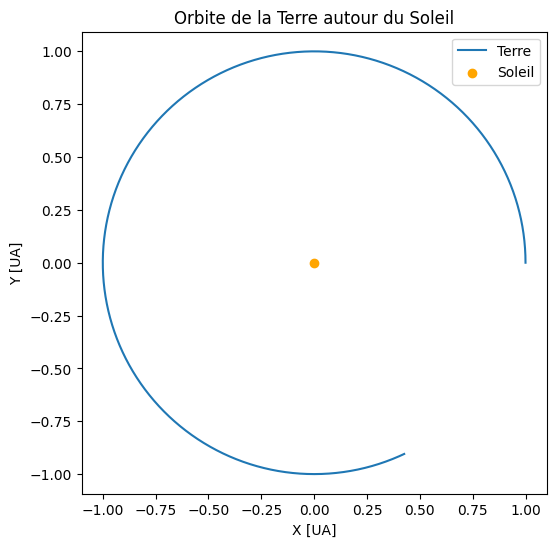

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Internal_constants import *
from Internal_functions import *

# Conditions initiales
R = 1.0, 0.0, 0.0    # Terre à 1 UA sur x
V = 0.0, 0.017202, 0.0  # vitesse initiale sur y (UA/jour)

# ----------------------------------------------------------
# Simulation
# ----------------------------------------------------------
tf = 300        # jours
h = 0.5         # pas de 1 jour
steps = int(tf/h)
R_hist = []

# --- CONFIGURATION ---
curr_state = np.array([*R, *V])  # vecteur plat [x, y, z, vx, vy, vz] shape (6,)
Masses = [M_Soleil_norm] # On prépare une liste ici
R_hist = []

# --- SIMULATION ---
for k in range(steps):
    t = k*h
    R_hist.append(curr_state[:3].copy())
    
    # Utilisation de la liste [M_Soleil] pour que Masses[0] fonctionne
    curr_state = rk4_step(compute_accel_sun_norm, t, curr_state, h)

R_hist = np.array(R_hist)

# Conversion en array numpy pour le plot (Format: steps x 3)
R_hist = np.array(R_hist) 
# ----------------------------------------------------------
# Visualisation
# ----------------------------------------------------------
plt.figure(figsize=(6,6))
plt.plot(R_hist[:,0], R_hist[:,1], label="Terre")
plt.scatter(0,0,color='orange',label='Soleil')
plt.xlabel('X [UA]')
plt.ylabel('Y [UA]')
plt.axis('equal')
plt.title("Orbite de la Terre autour du Soleil")
plt.legend()
plt.show()
